# Домашнее задание "Варианционные автоэнкодеры"

**Автор**: Ермекова Асель

В этом домашнем задании вам предстоит реализовать VAE для датасета картинок MNIST.

Вы научитесь обучать вариационный автоэнкодер (VAE) генерировать новые изображения с нуля. А также сможете управлять генерацией, указывая желаемый класс объекта, и оценивать качество результата с помощью метрики FID.

Это домашнее задание состоит из двух частей:

* **I часть.** Реализовать безусловную генерацию картинок при помощи VAE тренированную на датасете MNIST и оценить качество по метрике FID.
* **II часть.** Реализовать условную генерацию по классу и оценить качество по метрике FID.



     

Установите библиотеку для подсчета FID:

In [ ]:
!pip install pytorch-fid

## **I часть. Unconditional VAE (6 баллов)**

### Библиотеки

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from torchvision import datasets, transforms
from torchvision.io import read_image
import torchvision.transforms.functional as TF

from pytorch_fid import fid_score

import os
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device='cpu'

import warnings
warnings.filterwarnings('ignore')

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(1107)

### Датасет.

In [ ]:
image_size = 28
channels = 1
num_classes = 10

**Задание**: Скачайте датасет MNIST и подготовьте train dataloader.

In [ ]:
# --- Подготовка данных ---
batch_size = 256
transform = transforms.Compose([
    transforms.ToTensor(),
])

# повторных скачиваний при перезапуске ячейке не будет, пока существует директория data
# datasets.MNIST уже за нас разделил данные на train(60к изображений) и test(10к изображений)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('train len:', len(train_dataset))
print('test len:', len(test_dataset))

train len: 60000
test len: 10000


**Задание**: Для FID сохраните 10k реальных изображений из MNIST test части в папку

In [ ]:
folder='mnist_vae_real'
os.makedirs(folder, exist_ok=True)

saved = 0
for images, _ in test_loader:
    real_batch_size = images.size(0)
    for i in range(real_batch_size):
        if saved >= 10000:
            break
        save_image(images[i], f'{folder}/{saved}.png')
        saved += 1

file_count = len(os.listdir(folder))
print(f'В папке {folder} {file_count} файлов')

В папке mnist_vae_real 10000 файлов


**Задание**: Визуализируйте 5 рандомных сэмплов из тренировочных данных и 5 сэмплов из тестовых данных

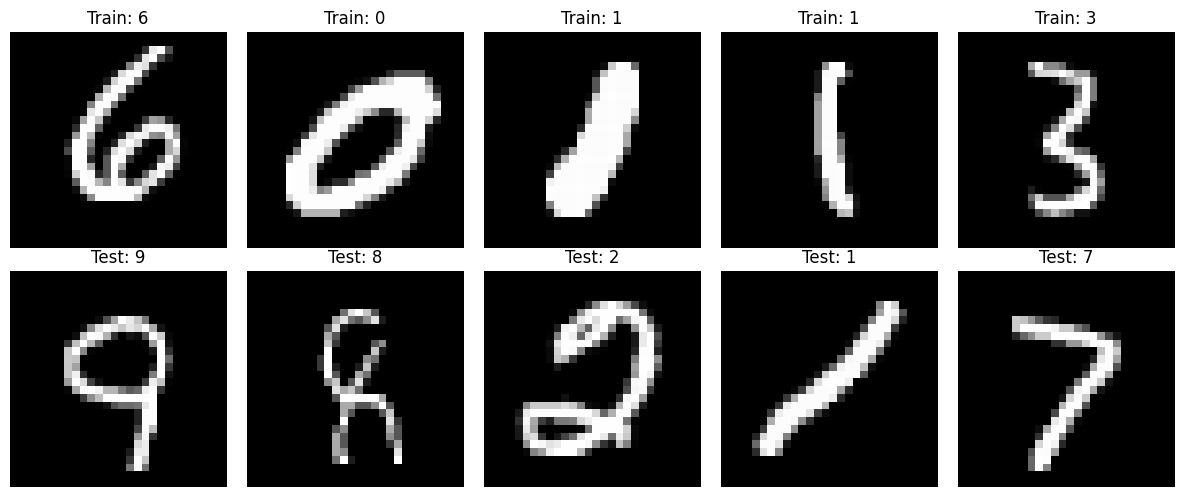

In [ ]:
train_indices = np.random.choice(len(train_dataset), 5, replace=False)
test_indices = np.random.choice(len(test_dataset), 5, replace=False)

train_samples = [train_dataset[i] for i in train_indices]
test_samples = [test_dataset[i] for i in test_indices]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (img, label) in enumerate(train_samples):
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title(f"Train: {label}")
    axes[0, i].axis('off')

for i, (img, label) in enumerate(test_samples):
    axes[1, i].imshow(img.squeeze(), cmap='gray')
    axes[1, i].set_title(f"Test: {label}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Модель

**Задание**: Реализуйте VAE архитектуру

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        hidden_dim1 = 1024
        hidden_dim2 = 512
        hidden_dim3 = 256

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(image_size * image_size, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.BatchNorm1d(hidden_dim3),
            nn.LeakyReLU(0.2),
        )

        # Мы определяем, что выходы этих слоев это вектор средних и логарифмов дисперсий
        # (мы будем их использовать в формулах так, а благодаря backpropagation, градиенты автоматически подстроют веса, чтобы минимизировать loss)
        self.fc_mu = nn.Linear(hidden_dim3, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim3, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim3),
            nn.BatchNorm1d(hidden_dim3),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim3, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim1, image_size * image_size),
            # генерируем [0, 1] для ч/б картинок
            nn.Sigmoid(),
        )

    def encode(self, x):
        # скрытое представление
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    # сэмплирования из нормального распределения(латентный вектор)
    def reparameterize(self, mu, logvar):
        # преобразуем логарифм дисперсии в стандартное отклонение(возводим в exp, чтобы убрать логарифм и берем квадртный корень, чтобы убрать квадрат)
        std = torch.exp(0.5 * logvar)
        # reparameterization trick, случайные числа из стандартного нормального распределения N(0, 1).
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x_new = self.decoder(z)
        # возвращаем картинке оригинальную форму. [784] -> [1, 28, 28]
        return x_new.view(-1, 1, image_size, image_size)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Loss

**Задание**: Напишите VAE Loss

KL-дивергенция для гауссиан:

$$
D_{KL}\left( q(z|x) \; \|\| \; p(z) \right) = -\frac{1}{2} \sum_{i=1}^d \left( 1 + \log \sigma_i^2 - \mu_i^2 - \sigma_i^2 \right)
$$

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    # насколько хорошо декодер восстанавливает исходное изображение
    reconstruction_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    # насколько апостериорное распределение (q(z|x)) (которое оценивает энкодер) отличается от априорного (p(z))
    # KL divergence: D_KL(q(z|x) || p(z))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss + kl_loss

### Тренировка

**Задание**: Обучите модель на датасете MNIST.

In [ ]:
latent_dim = 40  # MNIST VAEs often use 20–64
lr = 5e-4

In [ ]:
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

epochs = 40

model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device)
        recon_batch_x, mu, logvar = model(batch_x)
        loss = vae_loss(recon_batch_x, batch_x, mu, logvar)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {train_loss/len(train_loader.dataset):.4f}')

Epoch 1, Loss: 163.3005
Epoch 2, Loss: 126.5055
Epoch 3, Loss: 119.0215
Epoch 4, Loss: 115.4676
Epoch 5, Loss: 113.3207
Epoch 6, Loss: 111.7907
Epoch 7, Loss: 110.6225
Epoch 8, Loss: 109.6674
Epoch 9, Loss: 109.0054
Epoch 10, Loss: 108.3760
Epoch 11, Loss: 107.8577
Epoch 12, Loss: 107.3294
Epoch 13, Loss: 107.0016
Epoch 14, Loss: 106.7245
Epoch 15, Loss: 106.3444
Epoch 16, Loss: 106.0333
Epoch 17, Loss: 105.8407
Epoch 18, Loss: 105.5504
Epoch 19, Loss: 105.3157
Epoch 20, Loss: 105.1484
Epoch 21, Loss: 104.8523
Epoch 22, Loss: 104.6896
Epoch 23, Loss: 104.5135
Epoch 24, Loss: 104.3858
Epoch 25, Loss: 104.2404
Epoch 26, Loss: 104.0319
Epoch 27, Loss: 104.0150
Epoch 28, Loss: 103.8528
Epoch 29, Loss: 103.7055
Epoch 30, Loss: 103.5821
Epoch 31, Loss: 103.4020
Epoch 32, Loss: 103.3075
Epoch 33, Loss: 103.2217
Epoch 34, Loss: 103.0883
Epoch 35, Loss: 103.0325
Epoch 36, Loss: 102.9337
Epoch 37, Loss: 102.8310
Epoch 38, Loss: 102.7737
Epoch 39, Loss: 102.6929
Epoch 40, Loss: 102.5805


### Метрика

В этом разделе вам необходимо посчитать метрику FID.

**Что такое FID?**

**FID (Fréchet Inception Distance)** — это метрика качества генеративных моделей для изображений, которая измеряет **расстояние между распределениями признаков реальных и сгенерированных изображений** в пространстве предобученной нейросети (обычно Inception-v3).

Чем **ниже FID**, тем **ближе** сгенерированные изображения к реальным — как по **качеству**, так и по **разнообразию**.

Формула FID основана на предположении, что признаки в этом пространстве приблизительно распределены как **многомерное нормальное распределение**:

$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \mathrm{Tr}\left( \Sigma_r + \Sigma_g - 2\sqrt{\Sigma_r \Sigma_g} \right)
$$

где:
- $(\mu_r, \Sigma_r)$ — среднее и ковариационная матрица признаков **реальных** изображений,
- $(\mu_g, \Sigma_g)$ — то же для **сгенерированных** изображений,
- $\mathrm{Tr}(\cdot)$ — след матрицы.

> 🔹 FID = 0 означает полное совпадение распределений.  
> 🔹 Чем выше FID ↑ , тем качество или разнообразие генерации ниже ↓.

**Как считать FID на MNIST?**

Вычислите FID с помощью библиотеки [`pytorch-fid`](https://github.com/mseitzer/pytorch-fid):

```bash
python -m pytorch_fid real_mnist/ fake_mnist/ --device cuda
```

> **Важно**: несмотря на то, что признаки Inception-v3 не оптимальны для рукописных цифр, FID остаётся полезной **относительной метрикой** — она позволяет сравнивать разные модели между собой при одинаковых условиях предобработки.


**Задание:** Сгенерируйте и сохраните 10 тыс. изображений, выберите 10 тыс. реальных изображений из MNIST тестовой выборки и посчитайте FID между реальными и сгенерированными изображениями.

In [ ]:
folder = 'mnist_vae_fake'
os.makedirs(folder, exist_ok=True)

model.eval()
n_samples = 10000

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        z = torch.randn(batch_size, latent_dim).to(device)
        samples = model.decode(z)
        for j in range(samples.size(0)):
            idx = i + j
            if idx >= n_samples:
                break
            save_image(samples[j], f'mnist_vae_fake/{idx}.png')

In [ ]:
!python -m pytorch_fid mnist_vae_real mnist_vae_fake --device cuda

100% 200/200 [00:37<00:00,  5.37it/s]
100% 200/200 [00:37<00:00,  5.30it/s]
FID:  31.079501250184506


## **II Часть. Conditional VAE (6 баллов)**


Мы уже научились обучать обычный VAE на датасете картинок и получать новые картинки. Давайте теперь научимся обучать модель, которая сможет генерировать не просто рандомную картинку, которая похожа на картинки из датасета, а картинку из конкретного класса. Например, в MNIST датасете 10 классов (от 1 до 10) и мы хотим говорить модели "Сгенерируй мне только конкретно картинку с числом 3." и она должна теперь уже сгенерировать только картинку с числом 3. Как раз Conditional VAE это должен уметь делать и генерировать картинку, обуславливаясь на конкретный класс.


**Задание**. В этой части домашнего задания вам предстоит обучить Conditional VAE на MNIST. Это значит, что модель на вход должна принимать картинку и класс картинки.

**Метрика**. Вам нужно сгенерировать 1000 сэмплов на каждый класс и посчитать FID для каждого класса.

In [ ]:
class CVAE(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super(CVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        hidden_dim1 = 1024
        hidden_dim2 = 512
        hidden_dim3 = 256

        self.encoder = nn.Sequential(
            nn.Flatten(),
            # добавляем num_classes к входному слою encoder
            nn.Linear(image_size * image_size + num_classes, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim2, hidden_dim3),
            nn.BatchNorm1d(hidden_dim3),
            nn.LeakyReLU(0.2),
        )

        self.fc_mu = nn.Linear(hidden_dim3, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim3, latent_dim)

        self.decoder = nn.Sequential(
            # добавляем num_classes к входному слою decoder
            nn.Linear(latent_dim + num_classes, hidden_dim3),
            nn.BatchNorm1d(hidden_dim3),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim3, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim2, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim1, image_size * image_size),
            nn.Sigmoid(),
        )

    def encode(self, x, c):
        # переводим информацию о классе в вектор, например, 2 -> [0, 0, 1, 0, 0, 0, 0 ,0, 0, 0]
        c_onehot = nn.functional.one_hot(c, self.num_classes).float()
        # (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)
        # добавляем в картинку метки классов(one-hot-вектор) 784+10 для подачи в первый слой энкодера
        x = torch.cat([x, c_onehot], dim=1)

        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    # аналогично VAE
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        c_onehot = nn.functional.one_hot(c, self.num_classes).float()
        # добавляем в латентный вектор метки классов(one-hot-вектор) latent_dim+10 для подачи в первый слой декодера
        z = torch.cat([z, c_onehot], dim=1)

        x_new = self.decoder(z)
        return x_new.view(-1, 1, image_size, image_size)

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

In [ ]:
model = CVAE(latent_dim, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

epochs = 40

model.train()
for epoch in range(epochs):
  train_loss = 0
  for batch_x, labels in train_loader:
      batch_x = batch_x.to(device)
      labels = labels.to(device)
      recon_batch_x, mu, logvar = model(batch_x, labels)
      loss = vae_loss(recon_batch_x, batch_x, mu, logvar)

      train_loss += loss.item()

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
print(f'Epoch {epoch+1}, Loss: {train_loss/len(train_loader.dataset):.4f}')

Epoch 40, Loss: 98.6619


In [ ]:
folder_real='mnist_vae_real_classes'
folder_fake='mnist_vae_fake_classes'

os.makedirs(folder_real, exist_ok=True)
os.makedirs(folder_fake, exist_ok=True)

for i in range(10):
    os.makedirs(f'{folder_real}/{i}', exist_ok=True)
    os.makedirs(f'{folder_fake}/{i}', exist_ok=True)

n_samples_per_class = 1000

model.eval()

# генерация 1000 сэплов для каждого класса при помощи CVAE модели
with torch.no_grad():
    for label in range(num_classes):
        z = torch.randn(n_samples_per_class, latent_dim).to(device)
        c = torch.full((n_samples_per_class,), label, dtype=torch.long).to(device)
        samples = model.decode(z, c)
        for i in range(n_samples_per_class):
            save_image(samples[i], f'{folder_fake}/{label}/{i}.png')

# сохранение по 1000 реальных изображений каждого класса из тестовой части датасета MNIST
class_counts = {i: 0 for i in range(10)}
for img, label in test_dataset:
    if class_counts[label] < n_samples_per_class:
        save_image(img, f'{folder_real}/{label}/{class_counts[label]}.png')
        class_counts[label] += 1

    if all(count == n_samples_per_class for count in class_counts.values()):
        break


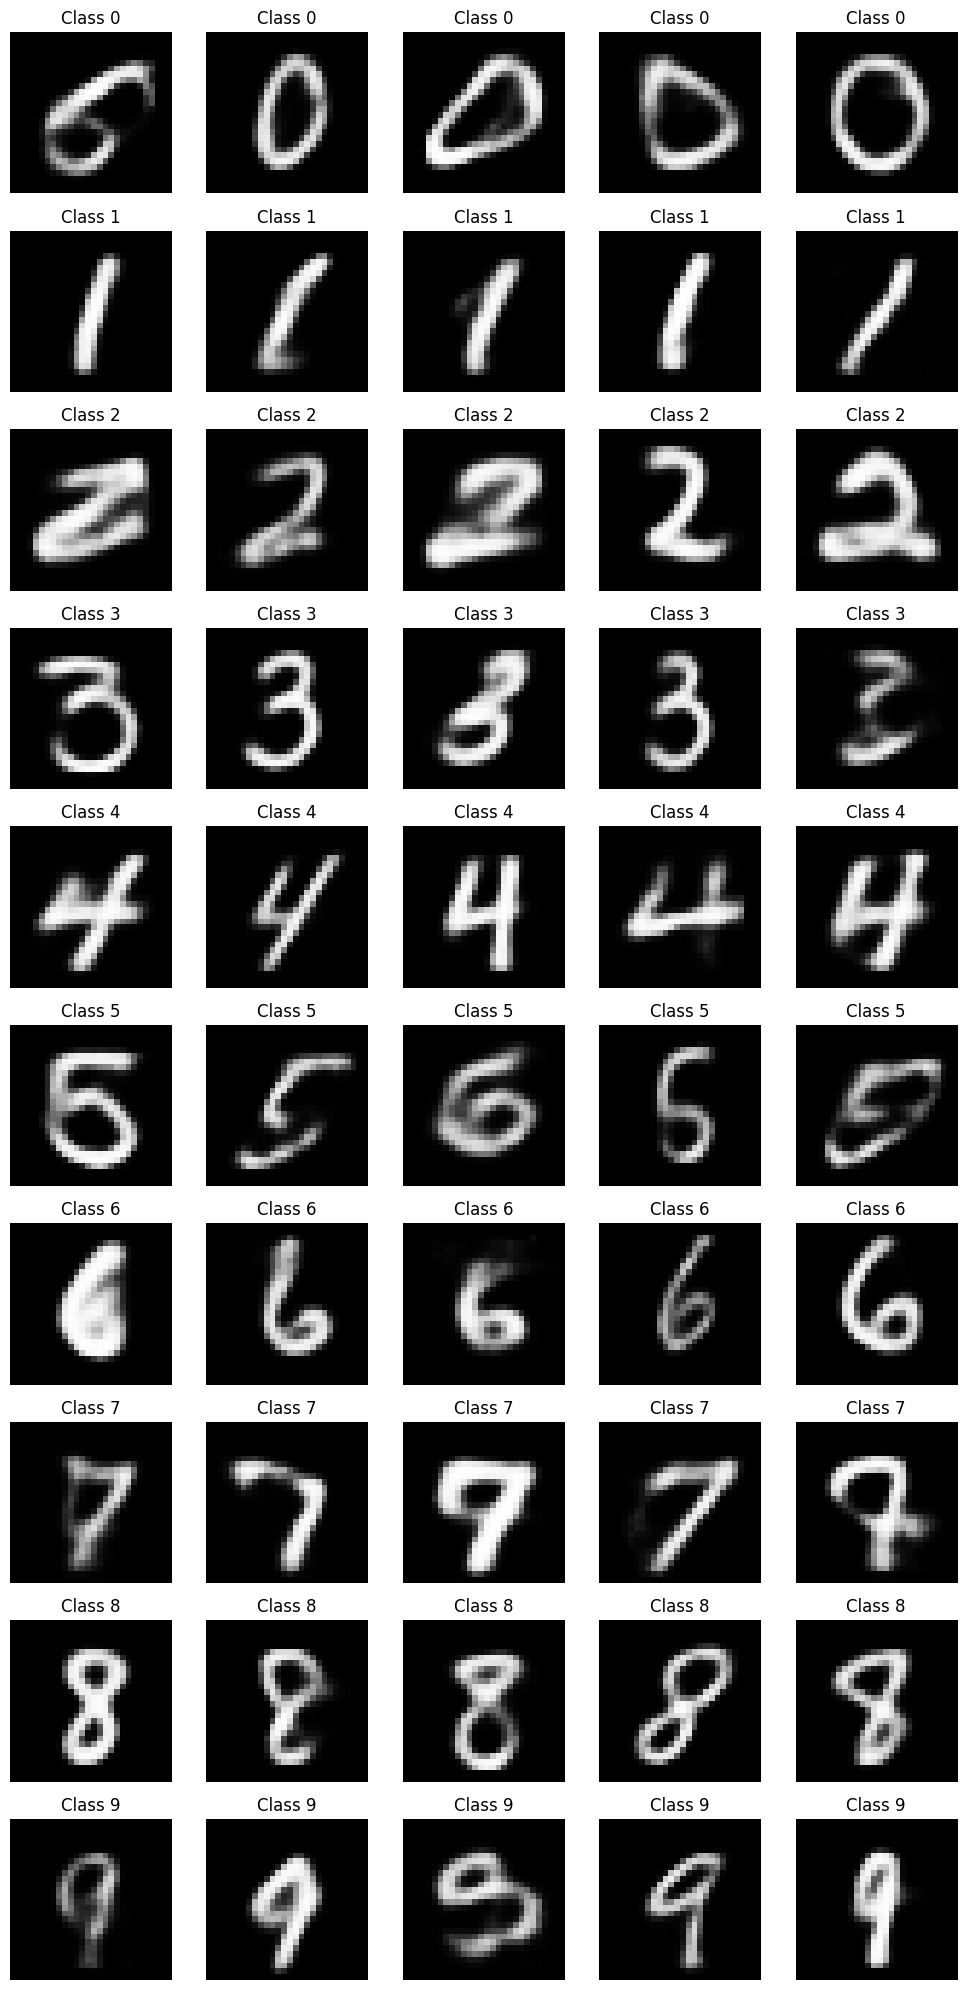

In [ ]:
root_dir = '/content/mnist_vae_fake_classes'
n_samples_per_class = 5

fig, axes = plt.subplots(num_classes, n_samples_per_class, figsize=(2 * n_samples_per_class, 2 * num_classes))

for label in range(num_classes):
    dir = f'{root_dir}/{label}'

    all_filenames = os.listdir(dir)
    random_filenames = random.sample(all_filenames, n_samples_per_class)

    for i, filename in enumerate(random_filenames):
        img_path = os.path.join(dir, filename)
        img = read_image(img_path)
        img = TF.to_pil_image(img)

        axes[label, i].imshow(img, cmap='gray')
        axes[label, i].set_title(f"Class {label}")
        axes[label, i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
for i in range(num_classes):
    print(f'Class {i}')
    !python -m pytorch_fid mnist_vae_real_classes/{i} mnist_vae_fake_classes/{i} --device cuda

Class 0
100% 20/20 [00:04<00:00,  4.87it/s]
100% 20/20 [00:03<00:00,  5.33it/s]
FID:  52.81252742897124
Class 1
100% 20/20 [00:04<00:00,  4.82it/s]
100% 20/20 [00:03<00:00,  5.32it/s]
FID:  56.08372421567648
Class 2
100% 20/20 [00:04<00:00,  4.90it/s]
100% 20/20 [00:03<00:00,  5.30it/s]
FID:  44.306236525007506
Class 3
100% 20/20 [00:04<00:00,  4.97it/s]
100% 20/20 [00:03<00:00,  5.22it/s]
FID:  37.26717789691912
Class 4
100% 20/20 [00:03<00:00,  5.04it/s]
100% 20/20 [00:03<00:00,  5.29it/s]
FID:  46.98328447554124
Class 5
100% 18/18 [00:03<00:00,  4.95it/s]
100% 20/20 [00:03<00:00,  5.23it/s]
FID:  41.48925818586136
Class 6
100% 20/20 [00:03<00:00,  5.05it/s]
100% 20/20 [00:03<00:00,  5.19it/s]
FID:  40.42785103233456
Class 7
100% 20/20 [00:04<00:00,  4.93it/s]
100% 20/20 [00:03<00:00,  5.27it/s]
FID:  49.918767532186536
Class 8
100% 20/20 [00:03<00:00,  5.03it/s]
100% 20/20 [00:03<00:00,  5.29it/s]
FID:  44.77177016403893
Class 9
100% 20/20 [00:04<00:00,  4.87it/s]
100% 20/20 [00:03<